In [1]:
from pathlib import Path

import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

print("Inference environment ready ✅")

Inference environment ready ✅


In [2]:
MODEL_DIR = Path("../models/trained")

MODEL_PATH = MODEL_DIR / "hog_linear_svm.joblib"
ENCODER_PATH = MODEL_DIR / "label_encoder.joblib"

svm_model = joblib.load(MODEL_PATH)
label_encoder = joblib.load(ENCODER_PATH)

print("Linear SVM loaded ✅")
print("Label encoder loaded ✅")
print("Classes:", len(label_encoder.classes_))
print(label_encoder.classes_)

Linear SVM loaded ✅
Label encoder loaded ✅
Classes: 29
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'nothing' 'space']


In [3]:
def extract_hog_features(image_path, img_size=128):

    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    # BGR -> RGB
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Resize
    image_resized = cv2.resize(
        image_rgb,
        (img_size, img_size)
    )

    # RGB -> Grayscale
    image_gray = cv2.cvtColor(
        image_resized,
        cv2.COLOR_RGB2GRAY
    )

    # HOG
    features = hog(
        image_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=True
    )

    return features.astype(np.float32)

In [4]:
print("Inference preprocessing function ready ✅")

Inference preprocessing function ready ✅


In [5]:
KAGGLE_TEST_DIR = Path(
    "../data/raw/asl_alphabet/"
    "asl_alphabet_test/"
    "asl_alphabet_test"
)

test_image = KAGGLE_TEST_DIR / "A_test.jpg"

print("Test image:", test_image)
print("Exists:", test_image.exists())

Test image: ../data/raw/asl_alphabet/asl_alphabet_test/asl_alphabet_test/A_test.jpg
Exists: True


In [6]:
# Predict one unseen ASL image

features = extract_hog_features(test_image)

print("Extracted feature shape:", features.shape)

# Model expects shape: (number_of_samples, number_of_features)
features = features.reshape(1, -1)

predicted_class_id = svm_model.predict(features)[0]

predicted_sign = label_encoder.inverse_transform(
    [predicted_class_id]
)[0]

print("\nPredicted class ID:", predicted_class_id)
print("Predicted Sign:", predicted_sign)

Extracted feature shape: (8100,)

Predicted class ID: 0
Predicted Sign: A


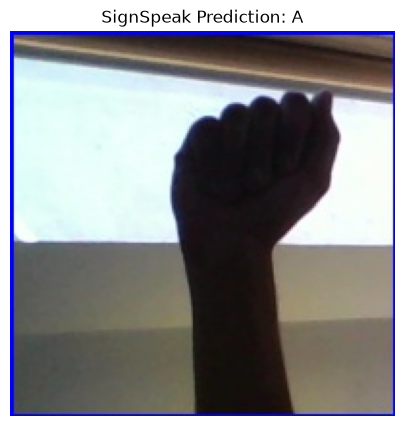

In [7]:
# Display image with model prediction

image = cv2.imread(str(test_image))

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(5, 5))

plt.imshow(image_rgb)

plt.title(
    f"SignSpeak Prediction: {predicted_sign}"
)

plt.axis("off")
plt.show()

In [8]:
# Predict all external Kaggle test images

results = []

test_files = sorted(
    KAGGLE_TEST_DIR.glob("*.jpg")
)

print("Number of external test images:", len(test_files))

for image_path in test_files:

    # True label from filename
    # Example: A_test.jpg -> A
    true_label = image_path.stem.replace("_test", "")

    # Extract HOG features
    features = extract_hog_features(image_path)
    features = features.reshape(1, -1)

    # Predict
    predicted_id = svm_model.predict(features)[0]

    predicted_label = label_encoder.inverse_transform(
        [predicted_id]
    )[0]

    # Check result
    correct = true_label == predicted_label

    results.append({
        "File": image_path.name,
        "Actual": true_label,
        "Predicted": predicted_label,
        "Correct": correct
    })

print("External test prediction completed ✅")

Number of external test images: 28
External test prediction completed ✅


In [9]:
import pandas as pd

external_results_df = pd.DataFrame(results)

external_results_df

,File,Actual,Predicted,Correct
0,A_test.jpg,A,A,True
1,B_test.jpg,B,B,True
2,C_test.jpg,C,C,True
3,D_test.jpg,D,D,True
4,E_test.jpg,E,E,True
5,F_test.jpg,F,F,True
6,G_test.jpg,G,G,True
7,H_test.jpg,H,H,True
8,I_test.jpg,I,I,True
9,J_test.jpg,J,J,True


In [10]:
correct_external = external_results_df["Correct"].sum()
total_external = len(external_results_df)

external_accuracy = (
    correct_external / total_external
)

print("=" * 50)
print("EXTERNAL KAGGLE TEST RESULTS")
print("=" * 50)

print("Total images:", total_external)
print("Correct:", correct_external)
print(
    "Incorrect:",
    total_external - correct_external
)

print(
    "Accuracy:",
    round(external_accuracy * 100, 2),
    "%"
)

print("=" * 50)

EXTERNAL KAGGLE TEST RESULTS
Total images: 28
Correct: 28
Incorrect: 0
Accuracy: 100.0 %


In [11]:
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

external_results_df.to_csv(
    RESULTS_DIR / "external_test_predictions.csv",
    index=False
)

print("External predictions saved ✅")
print("File: ../results/external_test_predictions.csv")

External predictions saved ✅
File: ../results/external_test_predictions.csv


In [12]:
custom_image = Path(
    "../data/custom_test/my_A.jpg"
)

print("Image exists:", custom_image.exists())

Image exists: False
